In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/raedmuhammed/data100/train.csv")
test = pd.read_csv("/kaggle/input/datasets/raedmuhammed/testdata/test.csv")
test_labels = pd.read_csv("/kaggle/input/datasets/raedmuhammed/testdata/test_labels.csv")
merged_test = pd.merge(test, test_labels, on='id')
test_clean = merged_test[merged_test['toxic'] != -1].reset_index(drop=True)



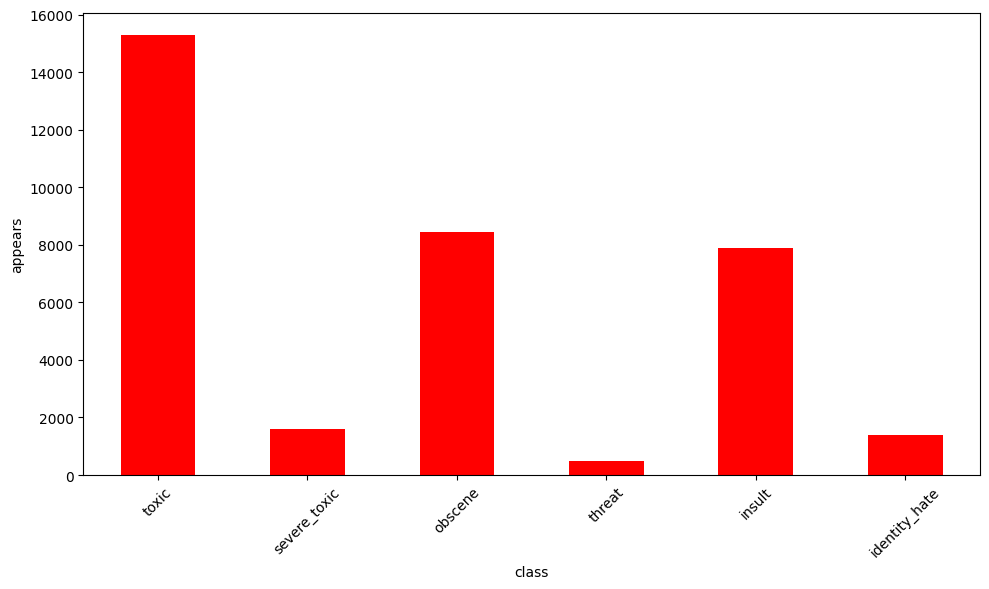

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# count how many times each label appears
counts_1 = df[classes].sum()

# bar plot to visualize class 
plt.figure(figsize=(10, 6))
counts_1.plot(kind='bar', color='red')

plt.xlabel('class')
plt.ylabel('appears')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(counts_1)

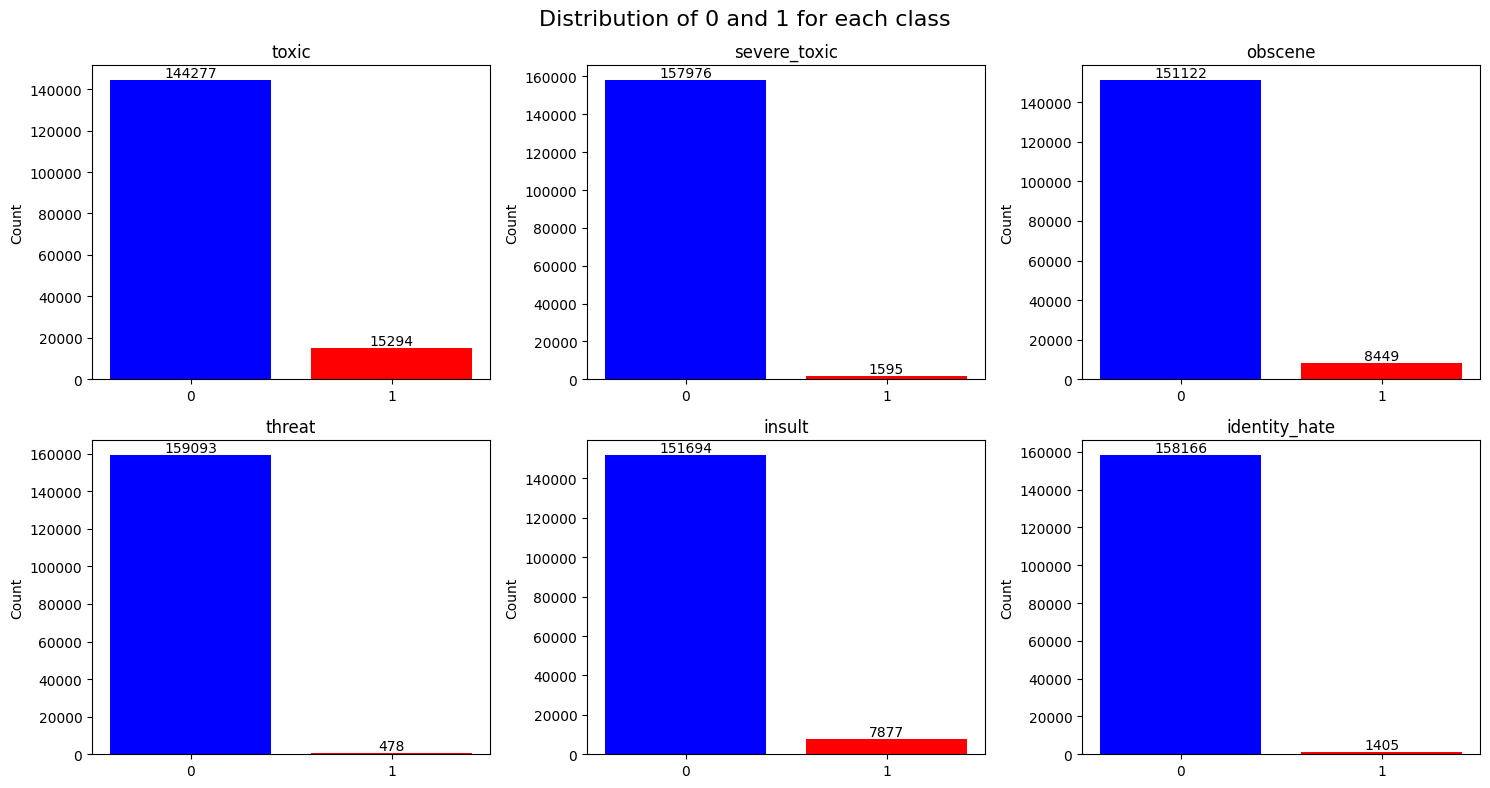

In [3]:
import seaborn as sns

# grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(classes):
    # count of 0s and 1s for this class
    value_counts = df[col].value_counts().sort_index()
    axes[i].bar(['0', '1'], [value_counts.get(0, 0), value_counts.get(1, 0)],
                color=['blue', 'red'])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    # show the count value above each bar
    for j, v in enumerate([value_counts.get(0, 0), value_counts.get(1, 0)]):
        axes[i].text(j, v, str(v), ha='center', va='bottom')

plt.suptitle('Distribution of 0 and 1 for each class', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re 

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = str(text)
    text = text.lower()
    # remove newlines 
    text = text.replace("\\n", " ")
    text = text.replace("\n", " ")
    # remove urls
    text = re.sub(r"http\S+|www\S+", " ", text)
    # remove ip addresses
    text = re.sub(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", " ", text)
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # remove numbers
    text = re.sub(r'\d+', ' ', text)

    words = word_tokenize(text)

    # lemmatize and remove stopwords 
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    clean_text = " ".join(clean_words)

    return clean_text

In [5]:
df["clean_text"] = df["comment_text"].apply(preprocess_text)

In [6]:
from skmultilearn.model_selection import IterativeStratification

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X = df["clean_text"]
y = df[label_cols].values

# multi-label stratified split (80% train, 20% val)
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.2, 0.8])
train_indices, val_indices = next(stratifier.split(X, y))

X_train_text = X.iloc[train_indices]
X_val_text = X.iloc[val_indices]
y_train = y[train_indices]
y_val = y[val_indices]

print("X_train_text:", X_train_text.shape)
print("X_val_text:", X_val_text.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train_text: (127656,)
X_val_text: (31915,)
y_train: (127656, 6)
y_val: (31915, 6)


In [7]:
from tensorflow.keras.layers import TextVectorization

vocab_size = 100000
sequence_length = 50

vectorize_layer = TextVectorization(
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length
)

# build vocab from training text only (avoid leakage from val)
print("Building vocabulary...")
vectorize_layer.adapt(X_train_text)
print("Vocabulary built!")

# convert text to padded integer sequences
X_train_seq = vectorize_layer(X_train_text)
X_val_seq = vectorize_layer(X_val_text)

print("X_train_seq shape:", X_train_seq.shape)
print("X_val_seq shape:", X_val_seq.shape)

I0000 00:00:1790381212.296090      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790381212.299132      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Building vocabulary...
Vocabulary built!
X_train_seq shape: (127656, 50)
X_val_seq shape: (31915, 50)


In [8]:
import tensorflow as tf

# cast to int32 for tf.data compatibility
X_train_seq = np.asarray(X_train_seq).astype(np.int32)
X_val_seq = np.asarray(X_val_seq).astype(np.int32)
y_train = y_train.astype(np.int32)
y_val = y_val.astype(np.int32)

# build tf.data pipeline for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train))
train_dataset = train_dataset.cache().shuffle(len(X_train_text)).batch(16).prefetch(8)

# validation pipeline
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val))
val_dataset = val_dataset.cache().batch(16).prefetch(8)

In [9]:

test_clean["clean_text"] = test_clean["comment_text"].apply(preprocess_text)

X_test_seq = vectorize_layer(test_clean["clean_text"])

label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
y_test = test_clean[label_cols].values.astype(np.int32)



In [10]:
np.save('X_train_seq.npy', X_train_seq)
np.save('X_val_seq.npy', X_val_seq)
np.save('y_train.npy', y_train)
np.save('y_val.npy', y_val)

X_test_seq = X_test_seq.numpy() if hasattr(X_test_seq, 'numpy') else np.array(X_test_seq)

np.save('X_test_seq', X_test_seq)
np.save('y_test.npy', y_test)